# MUSTAFA'S NOTEBOOK FOR DES, NO ONE ELSE EDITS 

**S24 Pipeline v2**

In [1]:
# sys.path.insert(0, "/home/ang/usd_ang/lib/python")
# os.environ["LD_LIBRARY_PATH"] = "/home/ang/usd_ang/lib"

#Some Code added by Mustafa in order to get it to work on my machine, comment out or something if it causes problems for you.
import sys
import os

# Go up from notebooks/ to the repo root
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
from S24.pipeline.sysml_pipeline_runner import run_sysml_to_json_pipeline

result = run_sysml_to_json_pipeline(
    sysml_file="ECLIPSE_Project2.sysml",
    verbose=1,
)


[WRITE] Full JSON → C:\Users\Mustafa Siddiqui\Desktop\School\GT\Classes\Semester 1\Introduction to Systems of Systems Engineering\SoS Grand Challenge\ISRU_Modeling\Github Code\S24-ArchitectingLunarBases\clean_database\json\ECLIPSE_Project2\ECLIPSE_Project2.json

[METADATA]
{
  "package": "ECLIPSE_LSP1",
  "num_parts": 5,
  "num_connections": 2,
  "validation_errors": []
}
[SUMMARY] Wrote 5 part files
[WRITE] HabitationModule → C:\Users\Mustafa Siddiqui\Desktop\School\GT\Classes\Semester 1\Introduction to Systems of Systems Engineering\SoS Grand Challenge\ISRU_Modeling\Github Code\S24-ArchitectingLunarBases\clean_database\json\ECLIPSE_Project2\assets\HabitationModule.json
[WRITE] ISRU_PLANT → C:\Users\Mustafa Siddiqui\Desktop\School\GT\Classes\Semester 1\Introduction to Systems of Systems Engineering\SoS Grand Challenge\ISRU_Modeling\Github Code\S24-ArchitectingLunarBases\clean_database\json\ECLIPSE_Project2\assets\ISRU_PLANT.json
[WRITE] landing_site → C:\Users\Mustafa Siddiqui\Deskto

In [3]:
from S24.validation.plotter import build_system_graph

data = result['data']
parts = data["parts"]
connections = data["connections"]

G = build_system_graph(parts, connections)
print(G)

print("\n[CONNECTIONS]")
for c in connections:
    print(c)

DiGraph with 5 nodes and 2 edges

[CONNECTIONS]
{'name': 'ISRUPlantToRover', 'type': 'LOXMovement', 'flow': 'LOX', 'from': {'part': 'ISRU_PLANT', 'port': 'ISRU_LOXPortOut'}, 'to': {'part': 'Rover', 'port': 'RoverFleet_LOXPortInOut'}}
{'name': 'RoverToPropellantDepot', 'type': 'LOXMovement', 'flow': 'LOX', 'from': {'part': 'Rover', 'port': 'RoverFleet_LOXPortInOut'}, 'to': {'part': 'Propellant_Depot', 'port': 'Propellant_LOXPortIn'}}


KeyError: 'ISRU_PLANT'

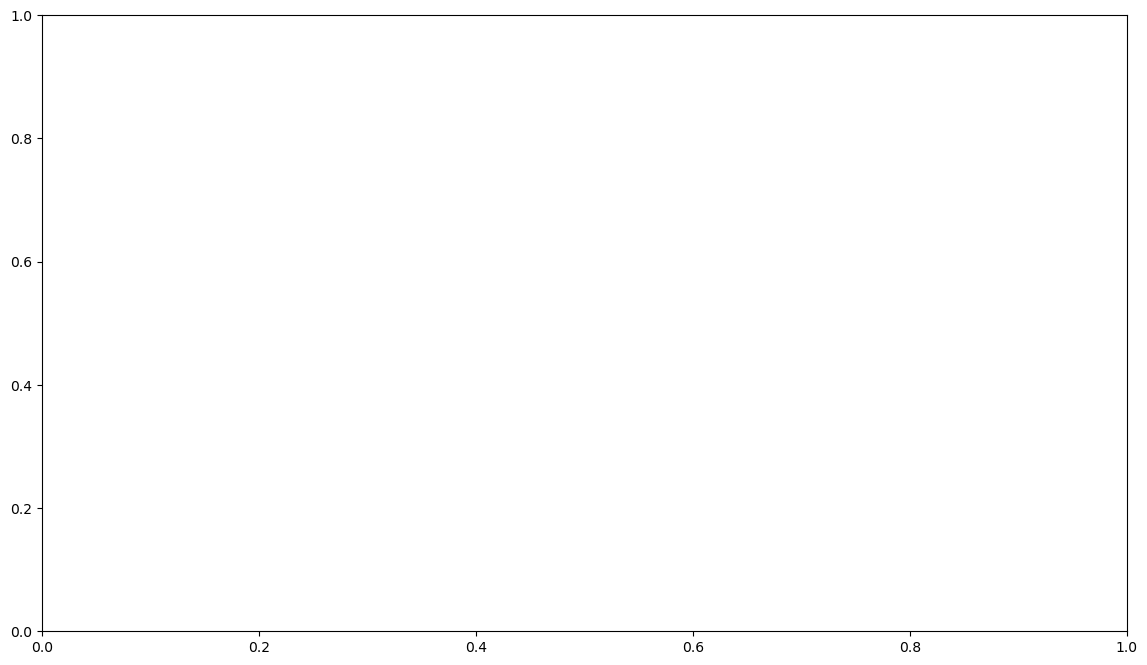

In [4]:
from S24.validation.plotter import plot_system_graph
plot_system_graph(G)

In [ ]:
active_nodes = [
    "ISRU_PLANT",
    "Rover",
    "Propellant_Depot"
] 

DES 

In [13]:
from S24.DES_pipeline_version.ISRU_DES_Model_V5_2_PV import run_scenario, check_scenario_validity

slider_value_dict = {
    "Num_Regolith_Rovers": 3,
    "Num_ISRU_Plants": 2,
    "Regolith_Haul_Distance": 1, #km
    "LOX_Haul_Distance": 1, #km
    "Rover_Energy_Consumption": 0.00034, #kWh/km/kg, Energy Per Kilometer Per Kilogram of Payload, supposed to replace the "Rover discharge rate" slider value
    "Rover_Travel_Time": 5, #hr/km
    "ISRU_Plant_Processing_Rate": 1600, #kg/hr
    "LOX_Transport_Threshold": 100, #kg, the amount of LOX at which the LOX rover will take the LOX at the ISRU plant and transport it to the launch and landing zone.
    "active_nodes": ["HabitationModule", "ISRUPlant", "LOXRover", "LaunchLandingZone", "RegolithRover", "SolarPowerSystem", "CommunicationModule"]
}

#For reference the following strings represent valid inputs for the "active_nodes" array:
# Active Nodes:
#   - HabitationModule
#   - ISRUPlant
#   - LaunchLandingZone
#   - LOXRover
#   - RegolithRover
#   - SolarPowerSystem
#   - CommunicationModule

# The check_scenario_validity function can be used to validate the active_nodes list and print any warnings or errors about incompatible node combinations or missing dependencies before running the scenario.  This is optional but can help catch issues early.
messages = check_scenario_validity(slider_value_dict["active_nodes"], raiseError=False)
print("\n[SCENARIO VALIDITY CHECK]")
if messages:
    for msg in messages:
        print(msg)
else:
    print("No issues found with the active_nodes configuration.")

#Run the Actual Scenario using the run_scenario function, passing in the slider_value_dict as the argument.  This will execute the DES model with the specified parameters and active nodes.
print("\n[RUNNING SCENARIO]")
run_scenario(slider_value_dict)


[SCENARIO VALIDITY CHECK]
No issues found with the active_nodes configuration.

[RUNNING SCENARIO]
ISRU Processing Plant – Active Nodes: CommunicationModule, HabitationModule, ISRUPlant, LOXRover, LaunchLandingZone, RegolithRover, SolarPowerSystem
The total energy consumed by Regolith Cargo Rover 1 is 1.36 kWh.
The total energy consumed by Regolith Cargo Rover 2 is 1.36 kWh.
The total energy consumed by Regolith Cargo Rover 3 is 1.36 kWh.
[5.00 hr] Rover delivered 4000 kg regolith
The total energy consumed by Regolith Cargo Rover 1 is 2.72 kWh.
[5.00 hr] Rover delivered 4000 kg regolith
The total energy consumed by Regolith Cargo Rover 2 is 2.72 kWh.
[5.00 hr] Rover delivered 4000 kg regolith
The total energy consumed by Regolith Cargo Rover 3 is 2.72 kWh.
[7.50 hr] ISRU Plant produced 10.11160806802452 kg of LOX from 4000 kg of Regolith using 237.2406742425153 kWh of Energy. There is now 10.11160806802452 kg of LOX stored, and 243.5098712446905 kWh has been consumed.
[7.50 hr] ISRU P

**Turn JSON into an structured python object and vet json graph validity and entries for usd**

In [ ]:
# from S24.jsonio import VettingProc

# vetting = VettingProc(source=str(JSON_FILE))
# vetted_parts = vetting.by_name

# list(vetted_parts.keys())

In [ ]:
# from S24.usd import USDBuilder

# builder = USDBuilder(
#     vetted_parts,
#     overwrite=True,
#     use_paths_from_vetted=False
# )

# outputs = builder.build_all_parts()
# outputs

# scene_path = builder.write_assembly_scene(
#     root_name="HabitationModule",
#     include_root_as_instance=True,
#     instanceable=False,
#     debug_refs=True
# )

# scene_path